In [2]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from statannotations.Annotator import Annotator
from helper_functions import draw_cov_ellipse, ordination_scatterplots
from scipy.stats import ttest_ind, mannwhitneyu, spearmanr, wilcoxon
from matplotlib_venn import venn2
from matplotlib_venn.layout.venn2 import DefaultLayoutAlgorithm as Venn2Layout

%matplotlib inline

In [3]:
#define source data file
source_path = '~/Desktop/Shenhav Lab/Joint-RPCA/source-data'

## Figure 2

### 2A

In [ ]:
#load subject ordinations
icluster_ord = pd.read_csv(f'{source_path}/Figure 2/A/iClusterPlus_subject_ordinations.csv', index_col=0)
intNMF_ord = pd.read_csv(f'{source_path}/Figure 2/A/intNMF_subject_ordinations.csv', index_col=0)
joint_rpca_ord = pd.read_csv(f'{source_path}/Figure 2/A/Joint-RPCA_subject_ordinations.csv', index_col=0)
mofa_ord = pd.read_csv(f'{source_path}/Figure 2/A/MOFA_subject_ordinations.csv', index_col=0)
spls_ord = pd.read_csv(f'{source_path}/Figure 2/A/sPLS_subject_ordinations.csv', index_col=0)

fig2_ord_lst = [joint_rpca_ord, mofa_ord, icluster_ord, intNMF_ord, spls_ord]
fig2_ord_title = ['Joint-RPCA','MOFA+','iCluster','intNMF','Multiblock sPLS']

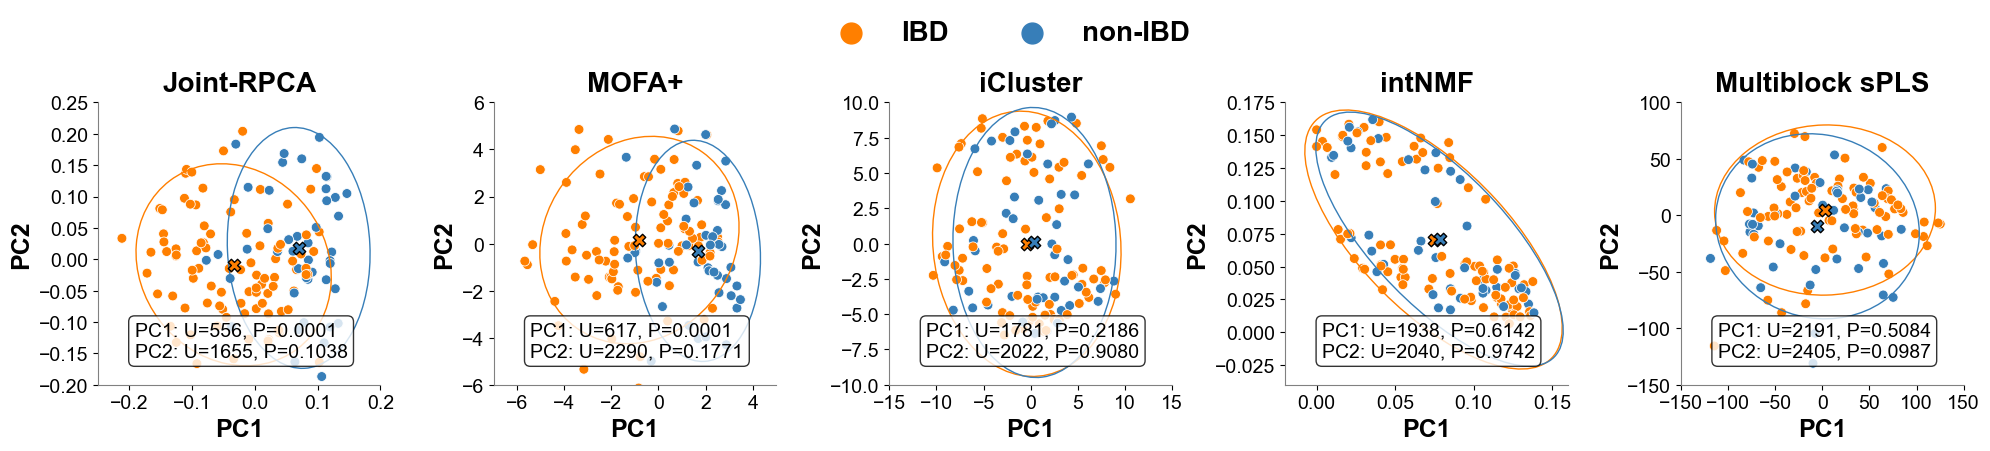

In [ ]:
fig, axn = plt.subplots(1, 5, figsize=(20, 4))

pal_ =  {'IBD':'#ff7f00', 'non-IBD':'#377eb8'}
lims_ = {'Joint-RPCA':[(-.2, .25), (-.25, .2)],
        'MOFA+': [(-6, 6), (-7, 5)],
        'iCluster':[(-10, 10), (-15, 15)],
        'intNMF':[(-0.04, 0.175), (-0.02, 0.16)],
        'Multiblock sPLS':[(-150, 100), (-150, 150)]}

for ax, ord_plt_, title_ in zip(axn.flatten(), fig2_ord_lst, fig2_ord_title):

    ord_plt_['diagnosis_binned'] = ord_plt_['diagnosis_binned'].replace('nonIBD', 'non-IBD')
    sns.scatterplot(x='PC1', y='PC2', hue='diagnosis_binned', s=50, 
                    data=ord_plt_, ax=ax, palette=pal_)

    # add ellipses + centroids
    centroids = []

    for group, color in pal_.items():
        subset = ord_plt_[ord_plt_['diagnosis_binned'] == group]

        X_group = subset[['PC1', 'PC2']].dropna().values

        if len(X_group) < 3:
            continue

        centroid = draw_cov_ellipse(ax, X_group, color=color, n_std=2, linewidth=1)

        if centroid is not None:
            centroids.append(centroid)

            # plot centroid
            ax.scatter(centroid[0], centroid[1], color=color, marker='X',
                       s=80, edgecolor='black', linewidth=1, zorder=4)

    txt_s = []
    props = dict(boxstyle='round', facecolor='white', alpha=0.8)
    for pc_ in ['PC1','PC2']:
        f_, p_ = mannwhitneyu(ord_plt_[ord_plt_.diagnosis_binned == 'IBD'].dropna(subset=[pc_])[pc_].values,
                              ord_plt_[ord_plt_.diagnosis_binned != 'IBD'].dropna(subset=[pc_])[pc_].values)
        if p_ < 0.0001:
            p_ = 0.0001
        txt_s.append('%s: U=%d, P=%.4f' % (pc_, f_, p_))
    ax.text(0.13, 0.1, '\n'.join(txt_s), fontsize=14, color='black', 
            fontname='Arial', transform=ax.transAxes, bbox=props)

    ax.set_xlabel('PC1', fontname='Arial',
                  color='black', weight='bold', fontsize=18)
    ax.set_ylabel('PC2', fontname='Arial',
                  color='black', weight='bold', fontsize=18)
    ax.set_title(title_, y=1.01, fontname='Arial',
                  color='black', weight='bold', fontsize=20)

    # fix backround
    ax.set_facecolor('white')
    sns.despine()
    for child in ax.get_children():
        if isinstance(child, matplotlib.spines.Spine):
            child.set_color('grey')

    for tick in ax.get_yticklabels():
        tick.set_fontproperties('arial')
        tick.set_color("black")
        tick.set_fontsize(14)
    for tick in ax.get_xticklabels():
        tick.set_fontproperties('arial')
        tick.set_color("black")
        tick.set_fontsize(14)
    ax.legend_.remove()
    ax.set_ylim(lims_[title_][0])
    ax.set_xlim(lims_[title_][1])
    
plt.tight_layout()
plt.subplots_adjust(wspace=0.4) 

#generate legend from last iterations     
handles, labels = ax.get_legend_handles_labels()
legend = ax.legend(handles[:], labels[:], bbox_to_anchor=(-1.65, 1.38),
                   prop={'size':20, 'weight':'bold', 'family': 'Arial'},
                   fancybox=True, framealpha=0, ncol=2, markerscale=2.5)
legend.get_title().set_fontsize('20')

#increase the line width in the legend 
for line in legend.get_lines()[:]:
    line.set_linewidth(4.0)
for line in legend.get_lines()[:]:
    line.set_linewidth(4.0)

plt.show()

### 2B

In [6]:
permanova_metrics = pd.read_csv(f'{source_path}/Figure 2/B/PERMANOVA-pseudo-F.csv', index_col=0)
mahalanobis_metrics = pd.read_csv(f'{source_path}/Figure 2/B/Mahalanobis-dist.csv', index_col=0)
apr_metrics = pd.read_csv(f'{source_path}/Figure 2/B/APR-results.csv', index_col=0)
apr_metrics['apr_error'] = 1 - apr_metrics['apr']
auc_metrics = pd.read_csv(f'{source_path}/Figure 2/B/AUC-ROC-results.csv', index_col=0)
auc_metrics['roc_error'] = 1 - auc_metrics['roc_auc']

metrics_lst = [permanova_metrics, mahalanobis_metrics, apr_metrics, auc_metrics]
metrics_titles_ = ['f_stat', 'mahalanobis', 'apr_error', 'roc_error']

In [9]:
auc_metrics

,dataset,method,fold,roc_auc,roc_error
0,meta_g_taxonomic_profiles_11,iCluster,0,0.533333,0.466667
1,meta_g_taxonomic_profiles_11,iCluster,1,0.725000,0.275000
2,meta_g_taxonomic_profiles_11,iCluster,2,0.600000,0.400000
3,meta_g_taxonomic_profiles_11,iCluster,3,0.450000,0.550000
4,meta_g_taxonomic_profiles_11,iCluster,4,0.633333,0.366667
...,...,...,...,...,...
475,meta_g_taxonomic_profiles,mixOmics,5,0.433333,0.566667
476,meta_g_taxonomic_profiles,mixOmics,6,0.666667,0.333333
477,meta_g_taxonomic_profiles,mixOmics,7,0.333333,0.666667
478,meta_g_taxonomic_profiles,mixOmics,8,0.366667,0.633333


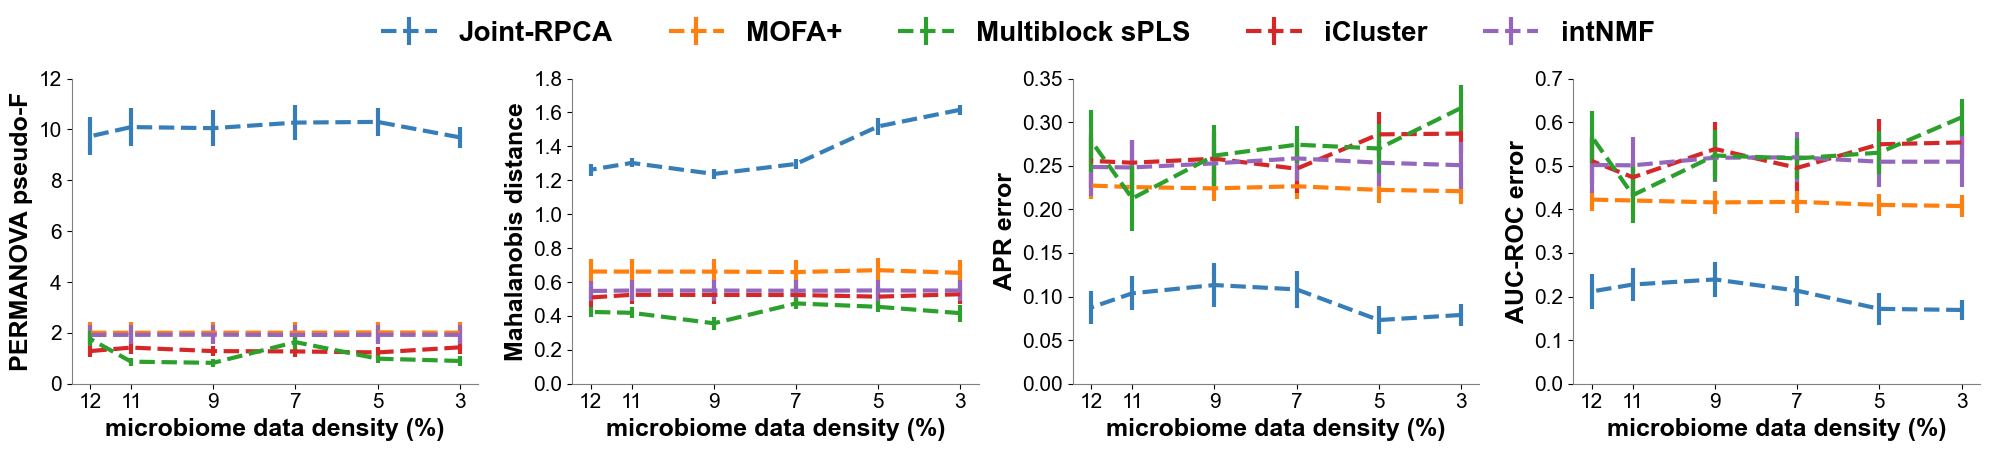

In [47]:
fig, axn = plt.subplots(1, 4, figsize=(20, 4))

cmap_ = {'Joint-RPCA':'#377eb8', 
         'MOFA':'#ff7f0e',
         'mixOmics':'#2ca02c',
         'iCluster':'#d62728',
         'intNMF':'#9467bd'}

metric_label = {'f_stat': 'PERMANOVA pseudo-F', 
                'mahalanobis': 'Mahalanobis distance', 
                'apr_error': 'APR error', 
                'roc_error': 'AUC-ROC error'}

ylims = {'f_stat': (0, 12), 'mahalanobis': (0, 1.8), 
         'apr_error': (0, 0.35), 'roc_error': (0, 0.7)}

for metric_df_, metric_, ax in zip(metrics_lst, metrics_titles_, axn.flatten()):

    metric_df_['density'] = [12 if x == 'meta_g_taxonomic_profiles' else int(x.split('_')[-1])
                             for x in metric_df_.dataset]
    
    for method_, all_df_plot in metric_df_.groupby('method'):
    
        all_df_grp = all_df_plot.groupby('density')
        ax.errorbar(all_df_grp.mean(numeric_only=True).index.values,
                    all_df_grp.mean(numeric_only=True)[metric_].values,
                    yerr=all_df_grp.sem(numeric_only=True)[metric_].values,
                    label=method_, lw=3, alpha=1, ls='--', c=cmap_[method_])
    
    ax.set_ylabel(metric_label[metric_], fontname='Arial', 
                  color='black', weight='bold', fontsize=18)

    ax.invert_xaxis()
    ax.set_xlabel('microbiome data density (%)', fontname='Arial', 
                  color='black', weight='bold', fontsize=18)

    # fix backround
    ax.set_facecolor('white')
    sns.despine()
    ax.set_ylim(ylims[metric_])

    for child in ax.get_children():
        if isinstance(child, matplotlib.spines.Spine):
            child.set_color('grey')

    for tick in ax.get_yticklabels():
        tick.set_fontproperties('arial')
        tick.set_color("black")
        tick.set_fontsize(15)
    for tick in ax.get_xticklabels():
        tick.set_fontproperties('arial')
        tick.set_color("black")
        tick.set_fontsize(15)

    # make x ticks evenly spaced
    true_densities = [12, 11, 9, 7, 5, 3]
    ax.set_xticks(true_densities)

plt.tight_layout()

# generate legend from last iterations     
handles, labels = axn[0].get_legend_handles_labels()

#relabel MOFA and mixOmics labels for clarity
labels = [l.replace('MOFA', 'MOFA+') for l in labels]
labels = [l.replace('mixOmics', 'Multiblock sPLS') for l in labels]

cmap_updated_ = {'Joint-RPCA':'#377eb8', 'MOFA+':'#ff7f0e',
                 'Multiblock sPLS':'#2ca02c', 'iCluster':'#d62728',
                 'intNMF':'#9467bd'}

order_new_ = [labels.index(k) for k in cmap_updated_.keys()]
legend = axn[0].legend([handles[i] for i in order_new_],
                       [labels[i] for i in order_new_],
                       loc=2, bbox_to_anchor=(0.7, 1.27),
                        prop={'size':20, 'weight':'bold', 'family': 'Arial'},
                        fancybox=False, framealpha=.0,
                        ncol=8, markerscale=1.5)
legend.get_title().set_fontsize('20')

# increase the line width in the legend 
for line in legend.get_lines()[:]:
    line.set_linewidth(4.0)
for line in legend.get_lines()[:]:
    line.set_linewidth(4.0)
plt.show()

## Figure 3

### 3A-B

In [5]:
biocrust_orig_density = pd.read_csv(f'{source_path}/Figure 3/A_B/original_density_table.csv', index_col=0)
biocrust_low_density = pd.read_csv(f'{source_path}/Figure 3/A_B/low_density_table.csv', index_col=0)

/var/folders/wc/r9njmvn106j5gvr496l3xw65jl16p6/T/ipykernel_45522/3779303026.py:65: UserWarning: Tight layout not applied. tight_layout cannot make axes width small enough to accommodate all axes decorations
  plt.tight_layout()


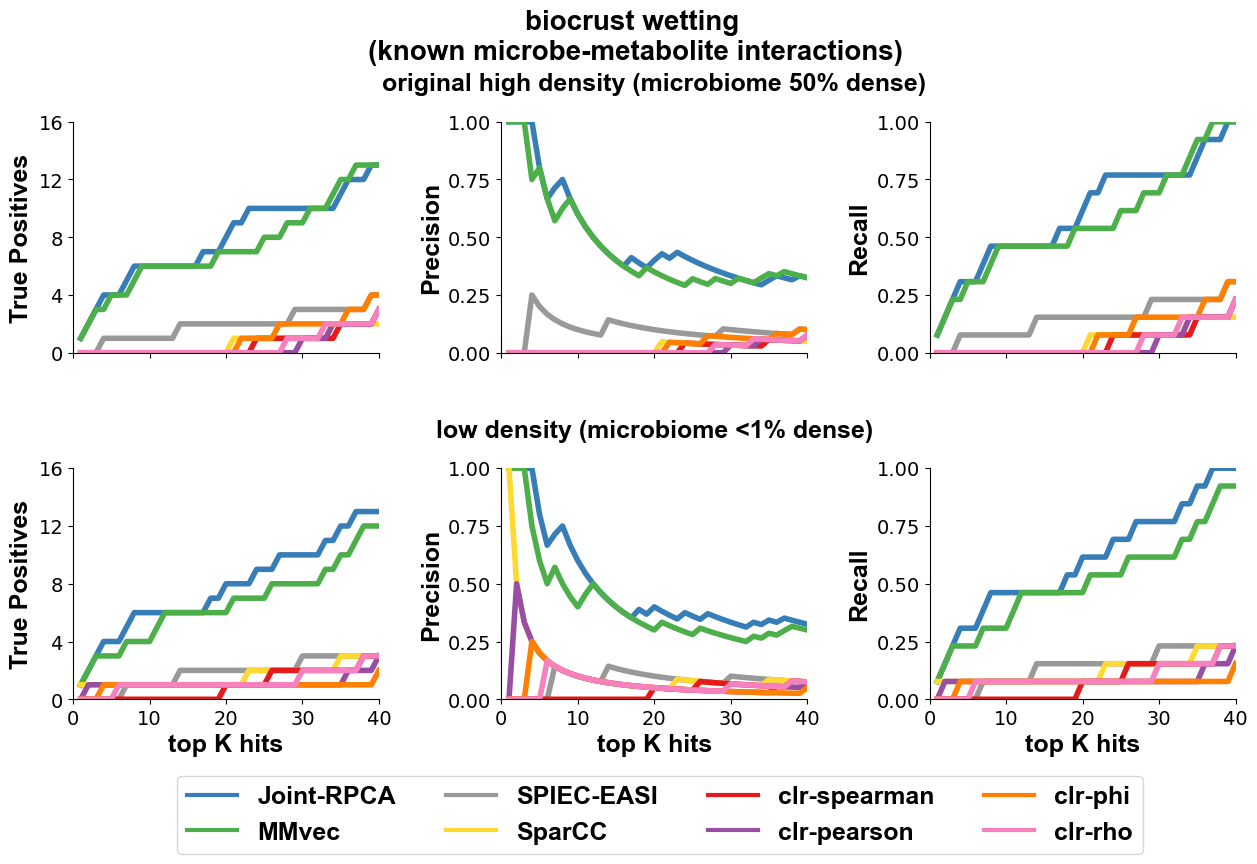

In [7]:
cmap_ = {'Joint-RPCA':'#377eb8', "MMvec":'#4daf4a',
         'spearman':'#e41a1c', 'pearson':'#984ea3',
         'phi':'#ff7f00', 'rho':'#f781bf',
         'SPIEC-EASI':'#999999', 'SparCC':'#ffd92f'}

fig, ax = plt.subplots(2, 3, figsize=(15, 7.5), sharex=True)

for ax_i, metric_, tbl_, density_ in zip([0, 1], ['TP', 'precision', 'recall'], 
                                         [biocrust_orig_density, biocrust_low_density],
                                         ['original high density (microbiome 50% dense)',
                                          'low density (microbiome <1% dense)']):

    def plot_stats(ax, attr='F score'):    
        ax.plot(tbl_[tbl_.method=='joint-rpca'][attr], label='Joint-RPCA', lw=4, c=cmap_['Joint-RPCA'])
        ax.plot(tbl_[tbl_.method=='mmvec'][attr], label='MMvec', lw=4, c=cmap_['MMvec'])
        ax.plot(tbl_[tbl_.method=='SPIEC-EASI'][attr], label='SPIEC-EASI', lw=4, c=cmap_['SPIEC-EASI'])
        ax.plot(tbl_[tbl_.method=='SparCC'][attr], label='SparCC', lw=4, c=cmap_['SparCC'])
        ax.plot(tbl_[tbl_.method=='spearman'][attr], label='clr-spearman', lw=4, c=cmap_['spearman'])
        ax.plot(tbl_[tbl_.method=='pearson'][attr], label='clr-pearson', lw=4, c=cmap_['pearson'])
        ax.plot(tbl_[tbl_.method=='phi'][attr], label='clr-phi', lw=4, c=cmap_['phi'])
        ax.plot(tbl_[tbl_.method=='rho'][attr], label='clr-rho', lw=4, c=cmap_['rho'])
        ax.set_ylabel(attr, color='black', weight='bold', fontsize=18, fontname='Arial')
        ax.tick_params(axis="x", labelsize=14)
        ax.tick_params(axis="y", labelsize=14)
        ax.xaxis.set_major_locator(plt.MaxNLocator(4))
        ax.yaxis.set_major_locator(plt.MaxNLocator(4))

    plot_stats(ax[ax_i][0], attr='TP')
    plot_stats(ax[ax_i][1], attr='precision')
    plot_stats(ax[ax_i][2], attr='recall')
    ax[ax_i][0].set_ylim(0, 16)
    ax[ax_i][1].set_ylim(0, 1)
    ax[ax_i][2].set_ylim(0, 1)

    ax[ax_i][0].set_ylabel('True Positives', fontsize=18, weight='bold', fontname='Arial')
    ax[ax_i][1].set_ylabel('Precision', fontsize=18, weight='bold', fontname='Arial')
    ax[ax_i][2].set_ylabel('Recall', fontsize=18, weight='bold', fontname='Arial')
    for ax_ in ax[ax_i]:
        ax_.spines['right'].set_visible(False)
        ax_.spines['left'].set_visible(True)
        ax_.spines['bottom'].set_visible(True)
        ax_.spines['top'].set_visible(False)
        ax_.set_xticks(np.arange(0, 40+1, 10))
        ax_.set_xlim(0, 40)

    ax[ax_i][1].set_title(density_, y=1.1, color='black',
                          weight='bold', fontsize=18, fontname='Arial')
    
plt.subplots_adjust(hspace=0.5, wspace=0.4)

for i_ in range(3):
    ax[ax_i][i_].set_xlabel('top K hits', color='black', weight='bold', fontsize=18, fontname='Arial')

handles, labels = ax[ax_i][0].get_legend_handles_labels()
legend = ax[ax_i][0].legend(handles[:8], labels[:8], loc='center left', 
                            bbox_to_anchor=(0.3, -0.5), ncol=4, 
                            fontsize=14, prop={'size':18, 'weight':'bold', 
                                         'family':'Arial'},)
# increase the line width in the legend 
for line in legend.get_lines()[:]:
    line.set_linewidth(3.0)
for line in legend.get_lines()[:]:
    line.set_linewidth(3.0)

plt.tight_layout()
plt.suptitle('biocrust wetting \n(known microbe-metabolite interactions)',
             color='black', weight='bold', fontname='Arial',
             fontsize=20, y=1.03)
plt.show()

### 3C-D

In [ ]:
finrisk_runtime = pd.read_csv(f'{source_path}/Figure 3/C_D_E/C_finrisk_runtime.csv', index_col=0) #based on original data
finrisk_sim_runtime = pd.read_csv(f'{source_path}/Figure 3/C_D_E/D_simulations_runtime.csv', index_col=0) #data-driven simulations
pal_ = {'MMvec':'#4daf4a', 'Joint-RPCA':'#377eb8'} #for plotting

/var/folders/wc/r9njmvn106j5gvr496l3xw65jl16p6/T/ipykernel_45522/481137357.py:13: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(0, 10**4)


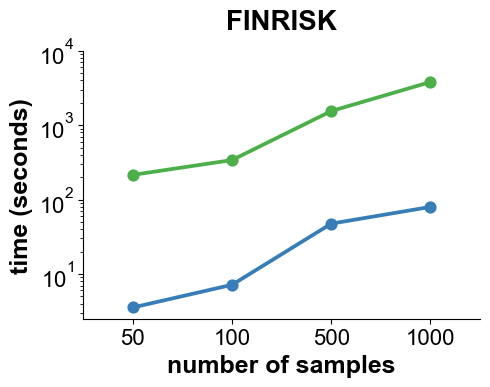

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(5, 4))

sns.pointplot(x='n-samples', y='time', hue='method', 
              data=finrisk_runtime[finrisk_runtime['n-samples'] < 2000], 
              palette=pal_, ax=ax)

ax.set_title('FINRISK', color='black', weight='bold', 
             fontsize=20, fontname='Arial', y=1.05)
ax.set_yscale('log')
sns.despine()
ax.set_ylim(0, 10**4)

for child in ax.get_children():
    if isinstance(child, matplotlib.spines.Spine):
        child.set_color('black')

for tick in ax.get_xticklabels():
    tick.set_fontproperties('arial')
    tick.set_color("black")
    tick.set_fontsize(16)

for tick in ax.get_yticklabels():
    tick.set_fontproperties('arial')
    tick.set_color("black")
    tick.set_fontsize(16)

ax.set_ylabel('time (seconds)', color='black', 
              weight='bold', fontsize=18, fontname='Arial')
ax.set_xlabel('number of samples', color='black',
              weight='bold', fontsize=18, fontname='Arial')
                  
ax.legend_.remove()
plt.tight_layout()
plt.show()

/var/folders/wc/r9njmvn106j5gvr496l3xw65jl16p6/T/ipykernel_45522/2236119885.py:11: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(0, 10**4)


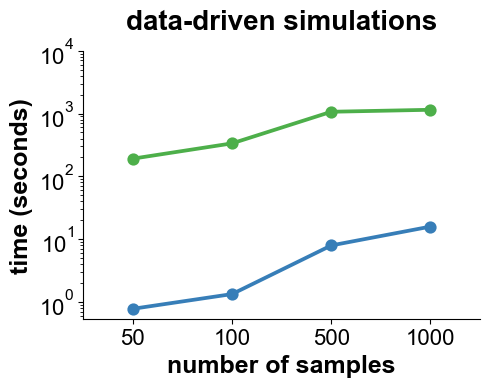

In [12]:
fig, ax = plt.subplots(1, 1, figsize=(5, 4))

sns.pointplot(x='n-samples', y='time', hue='method', 
              data=finrisk_sim_runtime[finrisk_sim_runtime['n-samples'] < 2000], 
              palette=pal_, ax=ax)

ax.set_title('data-driven simulations', color='black', weight='bold', 
             fontsize=20, fontname='Arial', y=1.05)
ax.set_yscale('log')
sns.despine()
ax.set_ylim(0, 10**4)

for child in ax.get_children():
    if isinstance(child, matplotlib.spines.Spine):
        child.set_color('black')

for tick in ax.get_xticklabels():
    tick.set_fontproperties('arial')
    tick.set_color("black")
    tick.set_fontsize(16)

for tick in ax.get_yticklabels():
    tick.set_fontproperties('arial')
    tick.set_color("black")
    tick.set_fontsize(16)

ax.set_ylabel('time (seconds)', color='black', 
              weight='bold', fontsize=18, fontname='Arial')
ax.set_xlabel('number of samples', color='black',
              weight='bold', fontsize=18, fontname='Arial')
                  
ax.legend_.remove()
plt.tight_layout()
plt.show()

### 3E

In [44]:
ihmp_runtime = pd.read_csv(f'{source_path}/Figure 3/C_D_E/E_ihmp-runtime.csv')
ucsd_runtime = pd.read_csv(f'{source_path}/Figure 3/C_D_E/E_ucsd-runtime.csv')

In [45]:
#create small df to connect lines between hues
ihmp_runtime_small = ihmp_runtime[(ihmp_runtime['% features'] > 9) & (ihmp_runtime['% features'] < 11)].copy()
ihmp_runtime_small2 = ihmp_runtime[(ihmp_runtime['% features'] > 23) & (ihmp_runtime['% features'] < 31) & 
                                       (ihmp_runtime['method'] == 'MMvec')].copy()
uc_runtime_small = ucsd_runtime[(ucsd_runtime['% features'] > 9) & (ucsd_runtime['% features'] < 12)].copy()

In [46]:
#the dfs below are used for labeling a few datapoints (runtimes)
ihmp_joint = ihmp_runtime[ihmp_runtime['method'] == 'Joint-RPCA'].copy()
ihmp_mmvec = ihmp_runtime[ihmp_runtime['method'] == 'MMvec'].copy()
ihmp_joint.reset_index(drop=True, inplace=True)
ihmp_mmvec.reset_index(drop=True, inplace=True)

uc_joint = ucsd_runtime[ucsd_runtime['method'] == 'Joint-RPCA'].copy()
uc_mmvec = ucsd_runtime[ucsd_runtime['method'] == 'MMvec'].copy()
uc_joint.reset_index(drop=True, inplace=True)
uc_mmvec.reset_index(drop=True, inplace=True)

In [47]:
#subtract one to % of features index
for df in [uc_joint, uc_mmvec]:
    df['% features index'] = df['% features index'] - 1

#add one to % of features index -- useful later for plotting
for df in [ihmp_joint, ihmp_mmvec, uc_joint, uc_mmvec]:
    df.index = df.index + 1

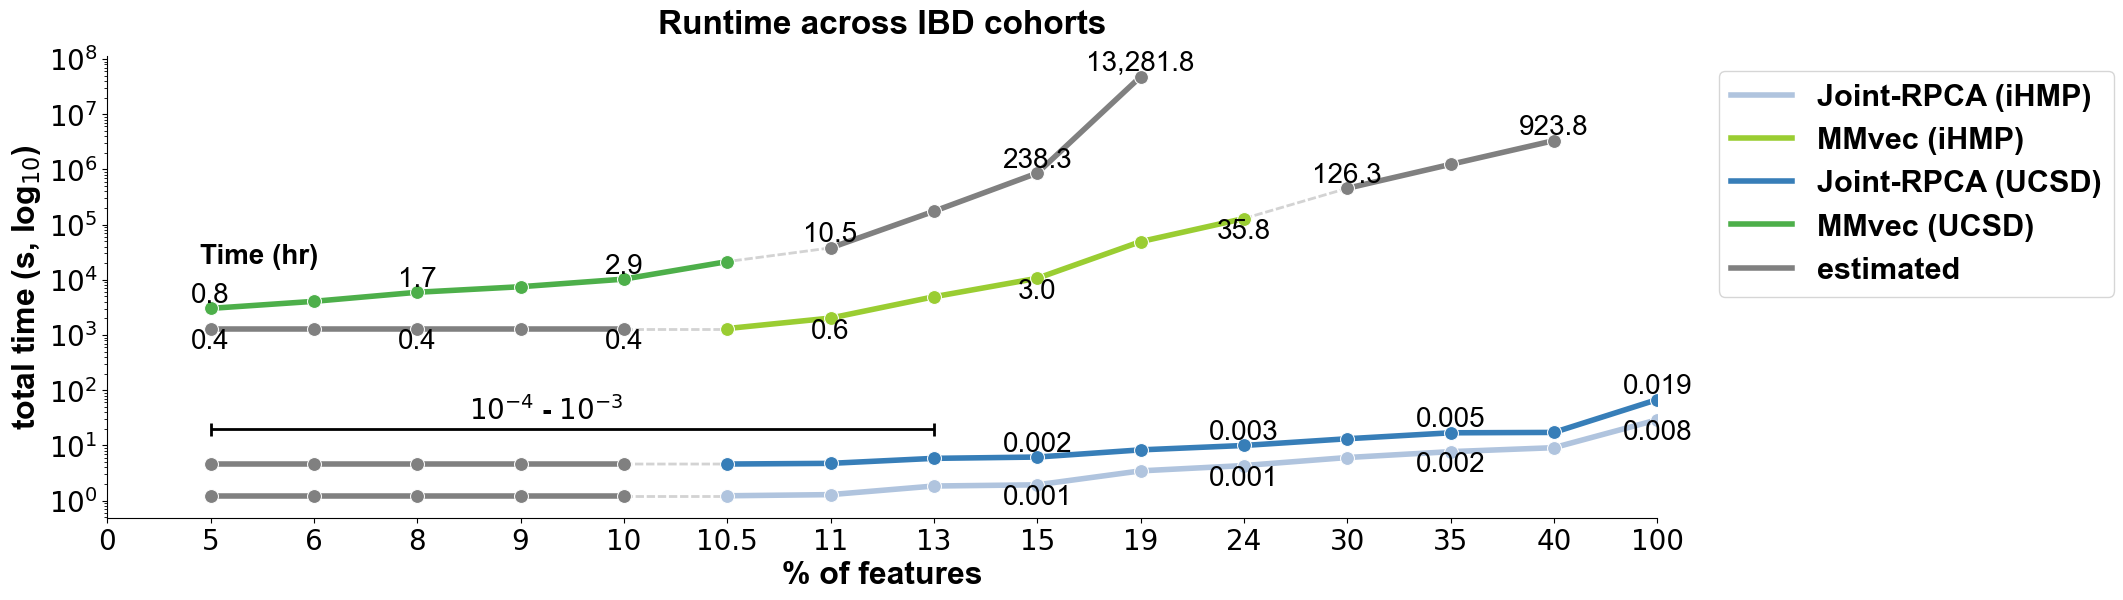

In [48]:
#estimate additional runtimes for MMvec using runtime
fig = plt.figure(figsize=(20, 6))

ihmp_palette = {'Joint-RPCA':'lightsteelblue', 'MMvec':'yellowgreen', 
                'joint_estimated':'gray', 'mmvec_estimated1':'gray',
                 'mmvec_estimated2':'gray'}
uc_palette = {'Joint-RPCA':'#377eb8', 'MMvec':'#4daf4a',
              'joint_estimated':'gray', 'mmvec_estimated':'gray'}
style_dict = {'Joint-RPCA': (3, 1), 'MMvec': (3, 1)}

#plot separate lines to connect between hues
ax1 = sns.lineplot(data=ihmp_runtime_small.copy(), x='% features index', y='time (s)', 
                   hue='method', palette={'Joint-RPCA':'lightgray', 'MMvec':'lightgray'},
                   style='method', dashes=style_dict, linewidth=2)
ax1.legend_.remove()

ax2 = sns.lineplot(data=ihmp_runtime_small2.copy(), x='% features index', y='time (s)', 
                   hue='method', palette={'Joint-RPCA':'lightgray', 'MMvec':'lightgray'},
                   style='method', dashes=style_dict, linewidth=2)
ax2.legend_.remove()

ax3 = sns.lineplot(data=uc_runtime_small.copy(), x='% features index', y='time (s)', 
                   hue='method', palette={'Joint-RPCA':'lightgray', 'MMvec':'lightgray'},
                   style='method', dashes=style_dict, linewidth=2)
ax3.legend_.remove()

#plot lines with hues added
ax4 = sns.lineplot(data=ihmp_runtime.copy(), x='% features index', y='time (s)', 
                    hue='method_detailed', linewidth=4,
                    hue_order=['Joint-RPCA','MMvec','joint_estimated',
                               'mmvec_estimated1','mmvec_estimated2'], 
                    palette=ihmp_palette, marker="o", markersize=10)

ax5 = sns.lineplot(data=ucsd_runtime.copy(), x='% features index', y='time (s)', 
                    hue='method_detailed', linewidth=4,
                    hue_order=['Joint-RPCA','MMvec','joint_estimated','mmvec_estimated'], 
                    palette=uc_palette, marker="o", markersize=10)
#log y axis
plt.yscale('log')
#increase font size
plt.ylabel('total time (s, log$_{10}$)', weight='bold',
           fontname='Arial', fontsize=23)
plt.yticks(fontsize=20)

#keep only half of the legend
handles, _ = plt.gca().get_legend_handles_labels()
handles = handles[5:]
handles_keep = np.concatenate([handles[0:2], handles[5:8]])
labels = ['Joint-RPCA (iHMP)', 'MMvec (iHMP)', 
          'Joint-RPCA (UCSD)', 'MMvec (UCSD)', 'estimated']
legend = plt.legend(handles_keep, labels, 
                    prop={'size':22, 'weight':'semibold', 'family':'Arial'}, 
                    ncol=1, bbox_to_anchor=(1.03, 1), fancybox=True)
for line in legend.get_lines()[:]:
    line.set_linewidth(4.0)

#get yticks
y_lim1 = plt.gca().get_ylim()
y_ticks = plt.gca().get_yticks()

#change xticks labels
all_p_features = sorted(list(ihmp_runtime['% features'].unique()))
all_p_features = [round(p, 1) for p in all_p_features]
all_p_features_plot = [0] + list(all_p_features)

all_p_features_plot_v2 = [0,5,6,8,9,10,10.5,11,13,15,19,24,30,35,40,100]
plt.xticks(list(range(0, len(all_p_features_plot))), 
           all_p_features_plot_v2, fontsize=20)
plt.xlim([0, len(all_p_features_plot)-1])
plt.xlabel('% of features', fontname='Arial', fontsize=23, weight='bold')

#add horizontal lines to show the runtime of the estimated points
plt.hlines(y=2e1, xmin=1, xmax=8, color='black', linestyle='-', lw=2)
plt.text(3.5, 3e1, "$10^{-4}$ - $10^{-3}$", ha='left', 
         fontsize=20, fontweight='semibold', fontname='Arial')
# Add vertical lines at the ends of the horizontal line
plt.vlines(x=1, ymin=1.5e1, ymax=2.5e1, color='black', lw=2)
plt.vlines(x=8, ymin=1.5e1, ymax=2.5e1, color='black', lw=2)

#add text to every other point to show the time in seconds
plt.text(0.9, 2e4, "Time (hr)", ha='left', fontsize=20, 
         fontweight='semibold', fontname='Arial')
for i, p in enumerate(all_p_features):
    j = i + 1
    if (i % 2 == 0 and j >= 8):
        #joint-rpca
        y_ihmp_joint = ihmp_joint.loc[j, 'time (s)']
        txt_ihmp_joint = round(y_ihmp_joint/3600, 3)
        plt.text(j, y_ihmp_joint, txt_ihmp_joint, fontsize=20,
                 ha='center', va='top', fontname='Arial')
        
        y_uc_joint = uc_joint.loc[j, 'time (s)']
        txt_uc_joint = round(y_uc_joint/3600, 3)
        plt.text(j, y_uc_joint, txt_uc_joint, fontsize=20,
                 ha='center', va='bottom', fontname='Arial')
    
    if (i % 2 == 0 and j <= 10) or (j==10):
        #mmvec - GOOD
        y_uc_mmvec = uc_mmvec.loc[j, 'time (s)']
        txt_uc_mmvec = round(y_uc_mmvec/3600, 1)
        txt_uc_mmvec = '{:,}'.format(txt_uc_mmvec)
        plt.text(j, y_uc_mmvec, txt_uc_mmvec, fontsize=20,
                 ha='center', va='bottom', fontname='Arial')
    
    if (i % 2 == 0 and j < 12):
        #mmvec
        y_ihmp_mmvec = ihmp_mmvec.loc[j, 'time (s)']
        txt_ihmp_mmvec = round(y_ihmp_mmvec/3600, 1)
        plt.text(j, y_ihmp_mmvec, txt_ihmp_mmvec, fontsize=20, 
                 ha='center', va='top', fontname='Arial')
        
    if (j==12) or (j==14):
        #mmvec
        y_ihmp_mmvec = ihmp_mmvec.loc[j, 'time (s)']
        txt_ihmp_mmvec = round(y_ihmp_mmvec/3600, 1)
        plt.text(j, y_ihmp_mmvec, txt_ihmp_mmvec, fontsize=20,
                 ha='center', va='bottom', fontname='Arial')

ax = plt.gca()
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(True)
ax.spines['bottom'].set_visible(True)
ax.spines['top'].set_visible(False)

plt.title('Runtime across IBD cohorts', y=1.03,
          color='black', weight='bold',
          fontsize=24, fontname='Arial')
plt.show()

## Figure 4

### 4A

In [56]:
iHMP_metab_lr = pd.read_csv(f'{source_path}/Figure 4/A/iHMP_Metabolomics_log_ratios.csv', index_col=0)
iHMP_metaG_lr = pd.read_csv(f'{source_path}/Figure 4/A/iHMP_MetaG_log_ratios.csv', index_col=0)
iHMP_metaT_lr = pd.read_csv(f'{source_path}/Figure 4/A/iHMP_MetaT_log_ratios.csv', index_col=0)
iHMP_prot_lr = pd.read_csv(f'{source_path}/Figure 4/A/iHMP_Proteomics_log_ratios.csv', index_col=0)
iHMP_virome_lr = pd.read_csv(f'{source_path}/Figure 4/A/iHMP_Virome_log_ratios.csv', index_col=0)

table_lst = [iHMP_virome_lr, iHMP_metaT_lr, iHMP_metaG_lr, iHMP_prot_lr, iHMP_metab_lr]
omic_order = ['virome_virmap_analysis', 'meta_t_ecs', 'meta_g_taxonomic_profiles',
              'HMP2_proteomics_ecs', 'HMP2_metabolomics']

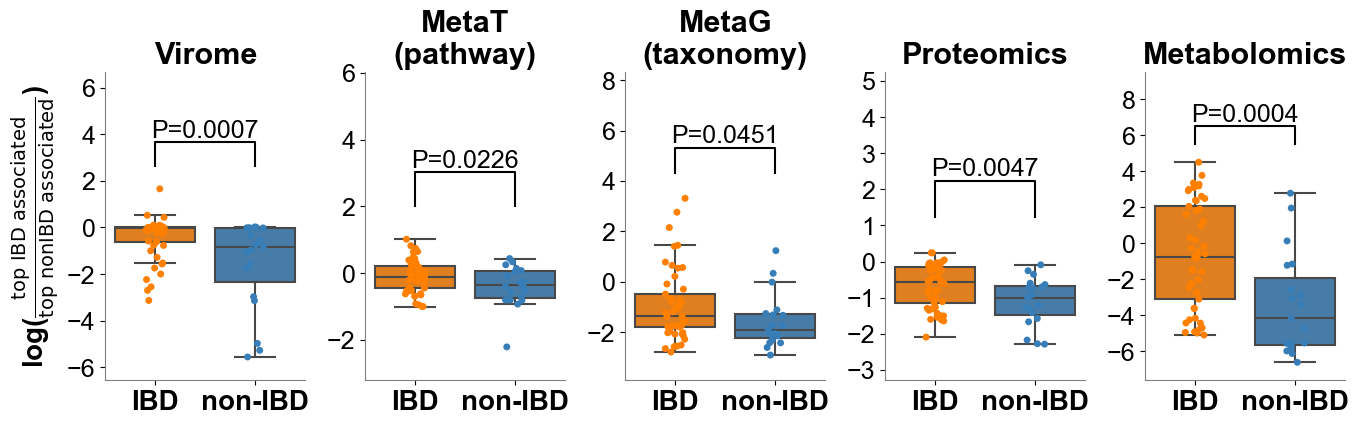

In [ ]:
title_bls = {'HMP2_metabolomics':'Metabolomics',
             'shared_meta_g_taxonomic_profiles':'MetaG\n(taxonomy)',
             'meta_g_taxonomic_profiles':'MetaG\n(taxonomy)',
             'virome_virmap_analysis':'Virome',
             'HMP2_proteomics_ecs':'Proteomics',
             'meta_t_ecs':'MetaT\n(pathway)'}
pal_ =  {'IBD':'#ff7f00', 'non-IBD':'#377eb8'}

fig, axn = plt.subplots(1, len(omic_order), figsize=(16, 4), 
                        sharex=True, sharey=False)
axn = axn.flatten()

for ax, omics_, tbl_ in zip(axn, omic_order, table_lst):
    
    tbl_['diagnosis_binned'] = [x.replace('nonIBD','non-IBD') for x in tbl_['diagnosis_binned']]
    sns.boxplot(y='log_ratio', x='diagnosis_binned', data=tbl_, ax=ax, palette=pal_, showfliers=False)
    sns.stripplot(y='log_ratio', x='diagnosis_binned', data=tbl_, ax=ax, palette=pal_)
    ax.set_title(title_bls[omics_], color='black', weight='bold', fontsize=22, fontname='Arial')
    
    # statistical annotation
    a_ = tbl_[tbl_.diagnosis_binned == 'IBD']['log_ratio'].dropna()
    b_ = tbl_[tbl_.diagnosis_binned != 'IBD']['log_ratio'].dropna()
    U_, p_ = ttest_ind(b_, a_, alternative='less')
    x1, x2 = 0, 1
    y, h, col = np.max([np.max(a_), np.max(b_)]) + 1, 1, 'k'
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.5, c=col)
    ax.text((x1+x2)*.5, y+h, "P=%.4f" %(p_), ha='center',
            va='bottom', color=col, fontsize=18, fontname='Arial')
    ax.set_ylim(np.min([np.min(a_), np.min(b_)]) - 1, 
                np.max([np.max(a_), np.max(b_)]) + 5)

for ax in axn:
    ax.set_xlabel('', color='black', weight='bold', fontsize=18, fontname='Arial')
    ax.set_ylabel('', color='black', weight='bold', fontsize=18, fontname='Arial')

    # fix backround
    ax.set_facecolor('white')
    ax.set_axisbelow(True)
    sns.despine()
    
    for child in ax.get_children():
        if isinstance(child, matplotlib.spines.Spine):
            child.set_color('grey')

    for tick in ax.get_yticklabels():
        tick.set_fontproperties('arial')
        tick.set_color("black")
        tick.set_fontsize(18)
    
    labels = [tick.get_text() for tick in ax.get_xticklabels()]
    labels = [l.replace('MOFA', 'MOFA+') for l in labels]
    labels = [l.replace('mixOmics', 'Multiblock sPLS') for l in labels]
    ax.set_xticklabels(labels)

    for tick in ax.get_xticklabels():
        tick.set_fontproperties('arial')
        tick.set_color("black")
        tick.set_weight("bold")
        tick.set_fontsize(20)

axn[0].set_ylabel('log($\\frac{\\mathrm{top\,\,IBD\,\,associated}}{\\mathrm{top\,\,nonIBD\,\,associated}}$)',
                  fontname='Arial', color='black', weight='bold', fontsize=20)
        
plt.subplots_adjust(wspace=0.3)
plt.show()


### B-C

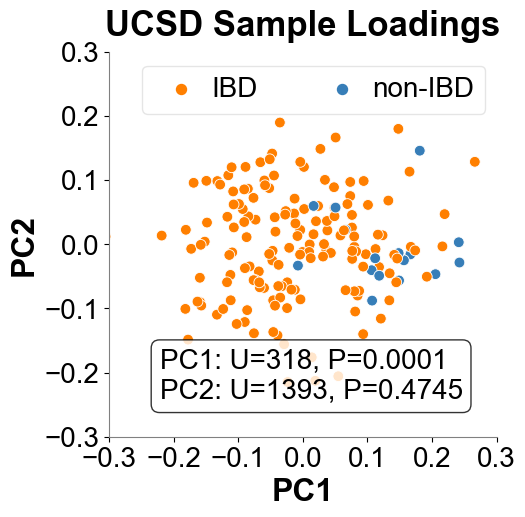

In [72]:
UCSD_ord = pd.read_csv(f'{source_path}/Figure 4/B_C/B_UCSD_subject_ordinations.csv', index_col=0)

fig, ax = plt.subplots(1, 1, figsize=(5, 5))
pal_ =  {'IBD':'#ff7f00', 'nonIBD':'#377eb8'}

sns.scatterplot(x='PC1', y='PC2', hue='Diagnosis', s=60,
                data=UCSD_ord, ax=ax, palette=pal_)
                
txt_s = []
props = dict(boxstyle='round', facecolor='white', alpha=0.8)
for pc_ in ['PC1','PC2']:
    f_, p_ = mannwhitneyu(UCSD_ord[UCSD_ord.Diagnosis == 'IBD'][pc_].values,
                          UCSD_ord[UCSD_ord.Diagnosis != 'IBD'][pc_].values)
    if p_ < 0.0001:
        p_ = 0.0001
    txt_s.append('%s: U=%d, P=%.4f' % (pc_, f_, p_))
ax.text(0.13, 0.1, '\n'.join(txt_s), fontsize=20, color='black', 
        fontname='Arial', transform=ax.transAxes, bbox=props)
    
ax.set_xlabel('PC1', color='black', weight='bold',
              fontname='Arial', fontsize=23)
ax.set_ylabel('PC2', color='black', weight='bold',
              fontname='Arial', fontsize=23)
ax.set_title('UCSD Sample Loadings', color='black', weight='bold',
              fontname='Arial', fontsize=25, y=1.02)

# fix backround
ax.set_facecolor('white')
ax.set_axisbelow(True)
sns.despine()
for child in ax.get_children():
    if isinstance(child, matplotlib.spines.Spine):
        child.set_color('grey')
for tick in ax.get_yticklabels():
    tick.set_fontproperties('arial')
    tick.set_color("black")
    tick.set_fontsize(20)
for tick in ax.get_xticklabels():
    tick.set_fontproperties('arial')
    tick.set_color("black")
    tick.set_fontsize(20)
    
# generate legend from last iterations     
handles, labels = ax.get_legend_handles_labels()
legend = ax.legend(handles[:], [l.replace('nonIBD','non-IBD') for l in labels], loc=2, 
                         bbox_to_anchor=(0.05, 1),
                         prop={'size':20, 'family':'Arial'},
                         fancybox=True, framealpha=.5, 
                         handletextpad=0.1, labelspacing=0.3,
                         ncol=2, markerscale=1.2)
# increase the line width in the legend 
for line in legend.get_lines()[:]:
    line.set_linewidth(4.0)
for line in legend.get_lines()[:]:
    line.set_linewidth(4.0)
    
ax.set_xlim(-.3, .3)
ax.set_ylim(-.3, .3)
plt.show()

In [ ]:
UCSD_metab_lr = pd.read_csv(f'{source_path}/Figure 4/B_C/C_UCSD_metabolomics_log_ratios.csv', index_col=0)
UCSD_metaG_lr = pd.read_csv(f'{source_path}/Figure 4/B_C/C_UCSD_metagenomics_log_ratios.csv', index_col=0)
UCSD_prot_lr = pd.read_csv(f'{source_path}/Figure 4/B_C/C_UCSD_metaproteomics_log_ratios.csv', index_col=0)

table_lst = [UCSD_metab_lr, UCSD_prot_lr, UCSD_metaG_lr]
omic_order = ['metabolomics_cohort_two_matched', 'metaproteomics_cohort_two_matched', 'metagenomics_cohort_two_matched']
title_bls = {'metagenomics_cohort_two_matched':'Metagenomics',
             'metaproteomics_cohort_two_matched':'Metaproteomics',
             'metabolomics_cohort_two_matched':'Metabolomics'}

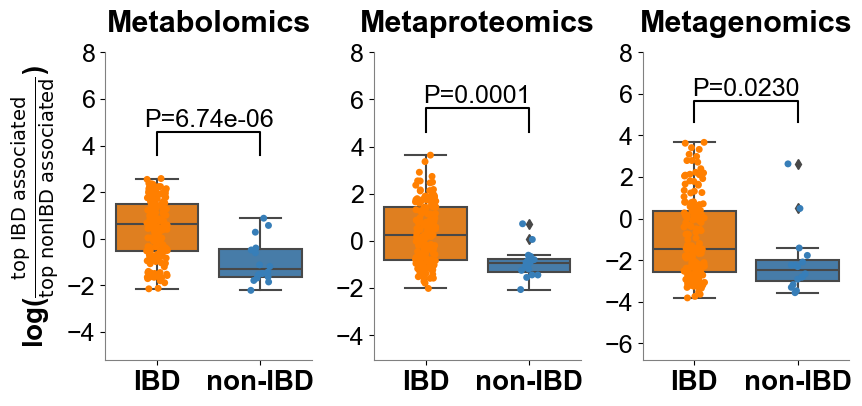

In [70]:
pal_ =  {'IBD':'#ff7f00', 'non-IBD':'#377eb8'}
fig, axn = plt.subplots(1, len(table_lst), figsize=((16/5)*3, 4), 
                        sharex=True, sharey=False)
axn = axn.flatten()

for ax, omics_, tbl_ in zip(axn, omic_order, table_lst):
    
    tbl_['Diagnosis'] = [x.replace('nonIBD','non-IBD') for x in tbl_['Diagnosis']]
    sns.boxplot(y='log_ratio', x='Diagnosis', data=tbl_, ax=ax, palette=pal_)
    sns.stripplot(y='log_ratio', x='Diagnosis', data=tbl_, ax=ax, palette=pal_)
    ax.set_title(title_bls[omics_], color='black', weight='bold', 
                 fontsize=22, fontname='Arial', y=1.04)
    
    # statistical annotation
    a_ = tbl_[tbl_.Diagnosis == 'IBD']['log_ratio'].dropna()
    b_ = tbl_[tbl_.Diagnosis != 'IBD']['log_ratio'].dropna()
    U_, p_ = ttest_ind(b_, a_)
    if 'e' in str(p_):
        p_ = str(p_)
        p_ = p_[:4] + p_[p_.index('e'):]
    else:
        p_ = str(p_)[:6]
    x1, x2 = 0, 1   # columns 'Sat' and 'Sun' (first column: 0, see plt.xticks())
    y, h, col = np.max([np.max(a_), np.max(b_)]) + 1, 1, 'k'
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.5, c=col)
    ax.text((x1+x2)*.5, y+h, "P=%s" %(p_), ha='center', fontname='Arial',
            va='bottom', color=col, fontsize=18)
    ax.set_ylim(np.min([np.min(a_), np.min(b_)]) - 3, 8)

for ax in axn:
    ax.set_xlabel('', color='black', weight='bold', fontsize=16)
    ax.set_ylabel('', color='black', weight='bold', fontsize=16)

    # fix backround
    ax.set_facecolor('white')
    ax.set_axisbelow(True)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(True)
    ax.spines['bottom'].set_visible(True)
    ax.spines['top'].set_visible(False)
    for child in ax.get_children():
        if isinstance(child, matplotlib.spines.Spine):
            child.set_color('grey')

    for tick in ax.get_yticklabels():
        tick.set_fontproperties('arial')
        tick.set_color("black")
        tick.set_fontsize(18)
    for tick in ax.get_xticklabels():
        tick.set_fontproperties('arial')
        tick.set_weight("bold")
        tick.set_color("black")
        tick.set_fontsize(20)

axn[0].set_ylabel('log($\\frac{\\mathrm{top\,\,IBD\,\,associated}}{\\mathrm{top\,\,nonIBD\,\,associated}}$)',
                  fontname='Arial', color='black', weight='bold', fontsize=20) 
plt.subplots_adjust(wspace=0.3)
plt.show()

### D

In [81]:
#load data
feature_correlations = pd.read_csv(f'{source_path}/Figure 4/D/iHMP_UCSD_correlation.csv', index_col=0)

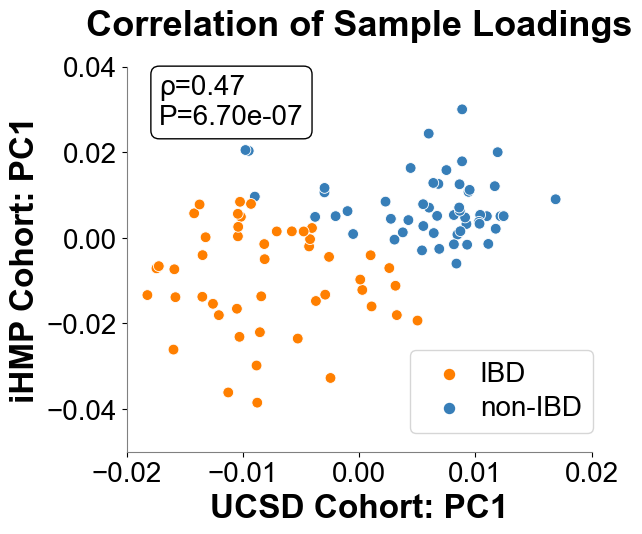

In [78]:
fig, ax = plt.subplots(figsize=(6, 5))

pal_ =  {'IBD':'#ff7f00', 'non-IBD':'#377eb8'}
sns.scatterplot(x='UCSD', y='iHMP', hue='grouping', 
                data=feature_correlations, palette=pal_, s=60)

# fix backround
ax.set_facecolor('white')
ax.set_axisbelow(True)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(True)
ax.spines['bottom'].set_visible(True)
ax.spines['top'].set_visible(False)
for child in ax.get_children():
    if isinstance(child, matplotlib.spines.Spine):
        child.set_color('grey')

for tick in ax.get_yticklabels():
    tick.set_fontproperties('arial')
    tick.set_color("black")
    tick.set_fontsize(20)
for tick in ax.get_xticklabels():
    tick.set_fontproperties('arial')
    tick.set_color("black")
    tick.set_fontsize(20)

ax.set_xlabel('UCSD Cohort: PC1', color='black', weight='bold',
              fontname='Arial', fontsize=24)
ax.set_ylabel('iHMP Cohort: PC1', color='black', weight='bold',
              fontname='Arial', fontsize=24)
ax.set_title('Correlation of Sample Loadings', color='black', weight='bold',
              fontname='Arial', fontsize=26, y=1.06)
ax.set_ylim(-0.05, 0.04)
ax.set_xlim(-0.02, 0.02)
ax.locator_params(axis='x', nbins=5)
ax.locator_params(axis='y', nbins=5)

rho, p_ = spearmanr(feature_correlations['UCSD'], 
                    feature_correlations['iHMP'])
if 'e' in str(p_):
    p_ = str(p_)
    p_ = p_[:4] + p_[p_.index('e'):]
else:
    p_ = str(p_)[:6]
stat_ = "ρ=%.2f\nP=%s" % (rho, p_)
    
props = dict(boxstyle='round', facecolor='white', edgecolor='black')
ax.text(0.07, 0.85, stat_, transform=ax.transAxes, fontsize=20, bbox=props, 
        fontname='Arial', ha='left')
    
# generate legend from last iterations     
handles, labels = ax.get_legend_handles_labels()
legend = ax.legend(handles[:], labels[:], loc=2, 
                         bbox_to_anchor=(0.58, 0.3),
                         prop={'size':20, 'family':'Arial'},
                         fancybox=True, framealpha=.8,
                         handletextpad=0.1, labelspacing=0.3,
                         ncol=1, markerscale=1.2)
legend.get_title().set_fontsize('20')
# increase the line width in the legend 
for line in legend.get_lines()[:]:
    line.set_linewidth(4.0)
for line in legend.get_lines()[:]:
    line.set_linewidth(4.0)

plt.show()

### E

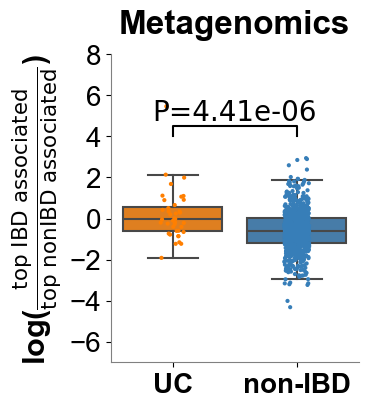

In [ ]:
#load data
AGP_lr = pd.read_csv(f'{source_path}/Figure 4/E/AGP_metagenomics_log_ratios.csv', index_col=0)

fig, ax = plt.subplots(1,1, figsize=(16/5, 4))

x = AGP_lr[AGP_lr['ibd_add'] == 'UC']['log_ratio'].values
y = AGP_lr[AGP_lr['ibd_add'] == 'non-IBD']['log_ratio'].values
t_, p_ = ttest_ind(x, y)

if 'e' in str(p_):
    p_ = str(p_)
    p_ = p_[:4] + p_[p_.index('e'):]
else:
    p_ = str(p_)[:6]

stat_ = "P=%s" % (p_)
cmap = {'UC':'#ff7f00', 'non-IBD':'#377eb8'}

sns.stripplot(x='ibd_add', y='log_ratio', order=['UC', 'non-IBD'],  
              palette=cmap, data=AGP_lr, ax=ax, s=3)
sns.boxplot(x='ibd_add', y='log_ratio', order=['UC', 'non-IBD'],  
            palette=cmap, data=AGP_lr, showfliers=False, ax=ax)

# fix backround
ax.set_facecolor('white')
ax.set_axisbelow(True)
sns.despine()
for child in ax.get_children():
    if isinstance(child, matplotlib.spines.Spine):
        child.set_color('grey')
for tick in ax.get_yticklabels():
    tick.set_fontproperties('arial')
    tick.set_color("black")
    tick.set_fontsize(20)
for tick in ax.get_xticklabels():
    tick.set_fontproperties('arial')
    tick.set_weight('bold')
    tick.set_color("black")
    tick.set_fontsize(20)

ax.set_ylim(-7, 8)
ax.set_ylabel('log($\\frac{\\mathrm{top\,\,IBD\,\,associated}}{\\mathrm{top\,\,nonIBD\,\,associated}}$)',
              fontname='Arial', color='black', weight='bold', fontsize=22)
ax.set_xlabel('')
ax.set_title('Metagenomics', fontname='Arial', color='black', 
             weight='bold', fontsize=24, y=1.04)

x1, x2 = 0, 1   # columns 'Sat' and 'Sun' (first column: 0, see plt.xticks())
y, h, col = 4, 0.5, 'k'
ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.5, c=col)
ax.text((x1+x2)*.5, y+h, stat_, ha='center', va='bottom', color=col, fontsize=20)
plt.show()

### F

In [94]:
left_panel = pd.read_csv(f'{source_path}/Figure 4/F/left_panel.csv', index_col=0)
middle_panel = pd.read_csv(f'{source_path}/Figure 4/F/middle_panel.csv', index_col=0)
right_panel = pd.read_csv(f'{source_path}/Figure 4/F/right_panel.csv', index_col=0)

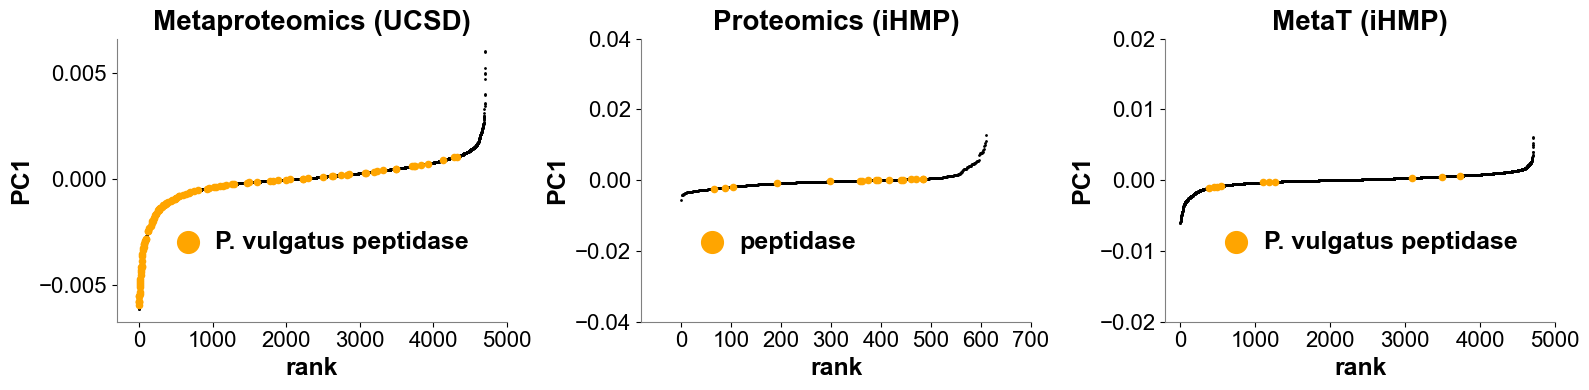

In [95]:
fig, axn = plt.subplots(1, 3, figsize=(16, 4))
pc_ = '0'

# (1)
ax = axn[0]
ax.scatter(left_panel[~(left_panel['plot'])]['rank'].values,
           left_panel[~(left_panel['plot'])][pc_].values,
           color='black', s=1)
ax.scatter(left_panel[left_panel['plot']]['rank'].values,
           left_panel[left_panel['plot']][pc_].values,
           color='orange', s=20, label='P. vulgatus peptidase')
ax.set_xlim(-300, 5000)

# (2)
ax = axn[1]
ax.scatter(middle_panel[~(middle_panel['plot'])]['rank'].values,
           middle_panel[~(middle_panel['plot'])][pc_].values,
           color='black', s=1)
ax.scatter(middle_panel[middle_panel['plot']]['rank'].values,
           middle_panel[middle_panel['plot']][pc_].values,
           color='orange', s=20, label='peptidase')
ax.set_ylim(-0.04, 0.04)
ax.set_xlim(-80, 700)

# (3)
ax = axn[2]
ax.scatter(right_panel[~(right_panel['plot'])]['rank'].values,
           right_panel[~(right_panel['plot'])][pc_].values,
           color='black', s=1)
ax.scatter(right_panel[right_panel['plot']]['rank'].values,
           right_panel[right_panel['plot']][pc_].values,
           color='orange', s=20, label='P. vulgatus peptidase')
ax.set_ylim(-0.02, 0.02)
ax.set_xlim(-200, 5000)

for ax in axn:
    # fix backround
    ax.set_facecolor('white')
    ax.patch.set_alpha(0.)
    ax.grid(False)
    ax.set_axisbelow(True)
    sns.despine()
    for child in ax.get_children():
        if isinstance(child, matplotlib.spines.Spine):
            child.set_color('grey')

    for tick in ax.get_yticklabels():
        tick.set_fontproperties('arial')
        tick.set_color("black")
        tick.set_fontsize(16)
    for tick in ax.get_xticklabels():
        tick.set_fontproperties('arial')
        tick.set_color("black")
        tick.set_fontsize(16)
    ax.locator_params(axis='y', nbins=5)

    ax.set_xlabel('rank', color='black', weight='bold',
                  fontsize=18, fontname='Arial')
    ax.set_ylabel('PC1', color='black', weight='bold',
                  fontsize=18, fontname='Arial')

    legend = ax.legend(loc=2,  bbox_to_anchor=(0.06, 0.4),
               prop={'size':18,'weight':'bold', 'family':'Arial'},
               title="", fancybox=True,framealpha=.0,
               ncol=1, markerscale=3.5, handletextpad=0.1)
    
axn[0].set_title('Metaproteomics (UCSD)', color='black',
                  weight='bold', fontsize=20, fontname='Arial')
axn[1].set_title('Proteomics (iHMP)', color='black',
                  weight='bold', fontsize=20, fontname='Arial')
axn[2].set_title('MetaT (iHMP)', color='black',
                  weight='bold', fontsize=20, fontname='Arial')

plt.tight_layout()
plt.show()

## Figure 5

### 5A

In [6]:
#save source data
joint_ord_plt = pd.read_csv(f'{source_path}/Figure 5/A/subject_ordinations_with_metadata.csv', index_col=0)
joint_ord_plt.head()

,PC1,PC2,PC3,PC4,season,subjects,add_0c,add_0c_group,facility,timepoint,traintest_0,traintest_1,traintest_2,traintest_3,traintest_4,traintest_5,traintest_6,traintest_7,traintest_8,traintest_9
soil.hip.CMU.16.05.2016.mo.day1,-0.018221,0.030873,-0.085463,0.115133,spring,CMU_Mrs._16_05,0.000000,initial,FIRS,1,train,train,train,train,train,train,train,train,train,train
soil.hip.CMU.16.05.2016.mo.day10,-0.035179,0.014736,-0.073839,0.077068,spring,CMU_Mrs._16_05,79.722222,active,FIRS,10,train,train,train,train,train,train,train,train,train,train
soil.hip.CMU.16.05.2016.mo.day12,-0.038744,0.017558,-0.089405,0.105295,spring,CMU_Mrs._16_05,110.277778,active,FIRS,12,test,test,test,test,test,test,test,test,test,test
soil.hip.CMU.16.05.2016.mo.day13,-0.017907,0.056791,-0.084153,0.111242,spring,CMU_Mrs._16_05,123.333333,active,FIRS,13,train,train,train,train,train,train,train,train,train,train
soil.hip.CMU.16.05.2016.mo.day14,-0.008599,0.091298,-0.083063,0.112228,spring,CMU_Mrs._16_05,136.666667,active,FIRS,14,train,train,train,train,train,train,train,train,train,train


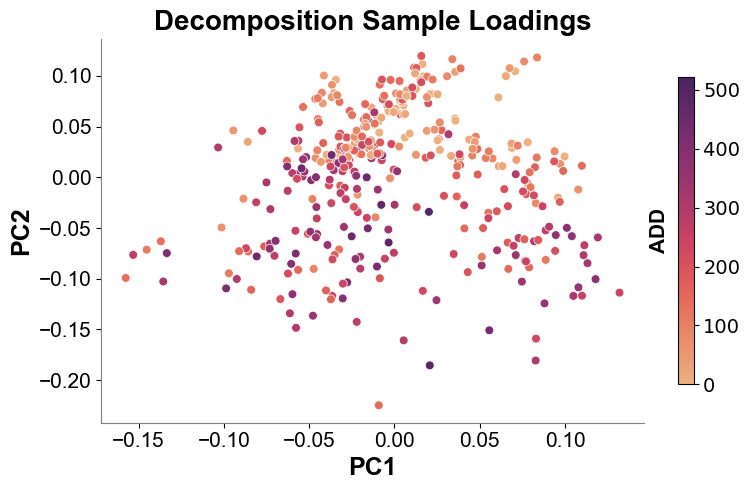

In [4]:
#plt.rcParams['axes.autolimit_mode'] = 'round_numbers'
ordination_scatterplots({'joint': joint_ord_plt}, x="PC1", y="PC2", 
                        hue="add_0c", hue_order=None, colorbar=True, cbar_label='ADD',
                        palette=sns.color_palette("flare", as_cmap=True),
                        title_={'joint': 'Decomposition Sample Loadings'},
                        markers=None, style=None, style_order=None, point_size=40,  
                        subplots=None, figsize=(8, 5), save_fig=False, save_path=None)

### 5B

In [15]:
rf_reg_add_ = pd.read_csv(f'{source_path}/Figure 5/B/ADD_regression_results.csv', index_col=0)
rf_reg_add_.head()

,Omic,Fold,MSE,MAE
0,18S_RPCA,traintest_9,18731.806034,112.675204
1,Joint_RPCA,traintest_2,9689.189625,76.783849
2,Metabolomics_RPCA,traintest_1,31334.878414,145.372844
3,Gene_Module_RPCA,traintest_2,9240.660508,77.819909
5,MAG_RPCA,traintest_13,15923.860889,106.439506


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Metabolomics_RPCA vs. Joint_RPCA: P=0.0007
Gene_Module_RPCA vs. Joint_RPCA: P=0.0045
18S_RPCA vs. Joint_RPCA: P=0.0302
MAG_RPCA vs. Joint_RPCA: P=0.0325


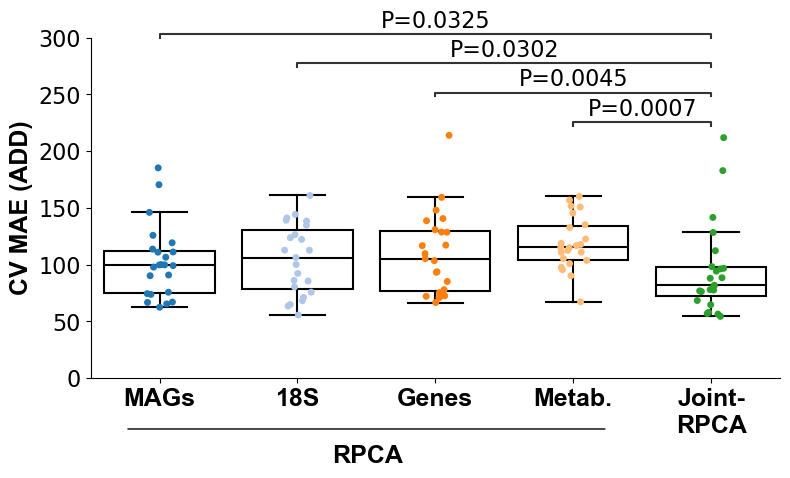

In [16]:
#focus on active vs all task
order = ['MAG_RPCA', '18S_RPCA', 'Gene_Module_RPCA', 
         'Metabolomics_RPCA', 'Joint_RPCA']
stat_pairs = [(omic, "Joint_RPCA") for omic in order if omic != "Joint_RPCA"]
plotting_params = {'x':'Omic', 
                   'data': rf_reg_add_, 'order':order}

boxPROPS = {
    'boxprops':{'facecolor':'none', 'edgecolor':'black'},
    'medianprops':{'color':'black'},
    'whiskerprops':{'color':'black'},
    'capprops':{'color':'black'}
}


fig, ax = plt.subplots(1, 1, figsize=(8, 5))
    
plotting_params['y'] = 'MAE'
sns.boxplot(ax=ax,  **{**plotting_params, **boxPROPS}, showfliers=False)
sns.stripplot(ax=ax, **plotting_params, palette='tab20')

#add statistical test
annotator = Annotator(ax, stat_pairs, **plotting_params)
less_compare = rf_reg_add_[rf_reg_add_.Omic == order[-1]].set_index('Fold')
y_ = less_compare['MAE'].values
stats_all = {}
for omic_ in order[:-1]:
    tmp_compare = rf_reg_add_[rf_reg_add_.Omic == omic_].set_index('Fold')
    tmp_compare = tmp_compare.reindex(less_compare.index)
    x_ = tmp_compare['MAE'].values
    t_, p_ = wilcoxon(y_, x_, alternative='less')
    stats_all[omic_] = {'test_stat':t_, 'p':p_}
stats_all = pd.DataFrame(stats_all).T 
annot_ = []
for p_ in stats_all.p:
    if 'e' in str(p_):
        p_ = str(p_)
        p_ = p_[:4] + p_[p_.index('e'):]
        annot_.append("P=%s" %p_)
    else:
        p_ = str(p_)[:6]
        annot_.append("P=%s" %p_)

annotator.configure(fontsize=16)
annotator.annotate_custom_annotations(annot_)

"""
Style
"""
sns.despine()
for child in ax.get_children():
    if isinstance(child, matplotlib.spines.Spine):
        child.set_color('black')
ax.set_facecolor('white')
ax.set_axisbelow(True)
ax.spines['left'].set_bounds(0, 300)
ax.set_ylim(0, 300)

for tick in ax.get_yticklabels():
    tick.set_weight('normal')
    tick.set_color("black")
    tick.set_fontsize(16)
fig.patch.set_facecolor('blue')
fig.patch.set_alpha(0)
ax.set_facecolor('white')
ax.patch.set_alpha(0)
ax.set_xticklabels([x.get_text().replace('_RPCA','').replace('Joint','Joint-\nRPCA').replace(
    'Gene_Module','Genes').replace('MAG','MAGs').replace('Metabolomics','Metab.')  
    for x in ax.get_xticklabels()])
for tick in ax.get_xticklabels():
    tick.set_fontproperties('arial')
    tick.set_weight('bold')
    tick.set_color("black")
    tick.set_fontsize(18)

ax.set_xlabel('')
ax.set_ylabel('CV MAE (ADD)', fontsize=18, 
              color='black', weight='bold', fontname='Arial')
ax.set_title('')

add_ = 0
ax.annotate('', xy=(0.05, -0.15 - add_), 
            xycoords='axes fraction', xytext=(0.75, -0.15 - add_),
arrowprops=dict(arrowstyle="-", color='black'))

ax.annotate('RPCA', xy=(0.35, -0.25 - add_), 
            xycoords='axes fraction', xytext=(0.35, -0.25 - add_), 
            fontsize=18, weight='bold', fontname='Arial')

plt.tight_layout()
plt.show()

### 5C

In [29]:
omic_venn_dfs = {}

for omic_id in ['metabolite', 'mag', '18S', 'gene_module']:
    omic_venn_dfs[omic_id] = pd.read_csv(f'{source_path}/Figure 5/C/{omic_id}_venn_features.csv',
                                         index_col=0)

In [34]:
display(omic_venn_dfs['mag'].head())
print(omic_venn_dfs['mag'].Overlap.value_counts())

,Top features,Overlap
0,CMU_active.final.40,RPCA only
1,CMU.bins.171,RPCA only
2,CMU.bins.320,RPCA only
3,CMU_early.final.2,RPCA only
4,CMU.bins.328,RPCA only


Both               11
RPCA only           8
Joint-RPCA only     8
Name: Overlap, dtype: int64


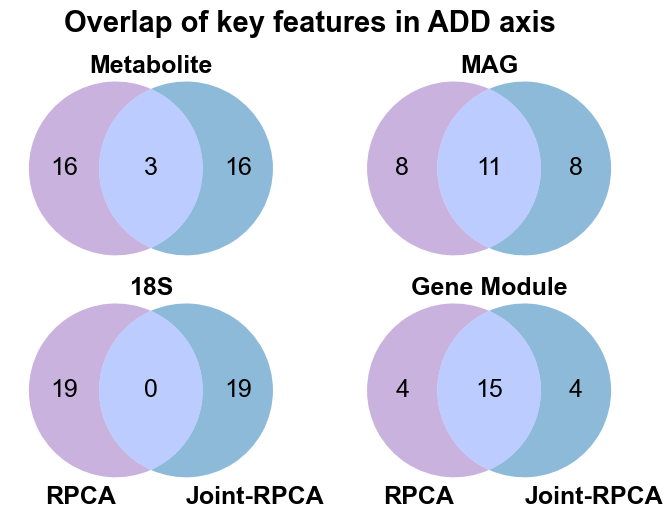

In [30]:
#plot a venn diagram per omic
omic_title = {'18S': '18S', 'mag': 'MAG', 
              'gene_module': 'Gene Module', 'metabolite': 'Metabolite'}

#RPCA
fig, axn = plt.subplots(2, 2, figsize=(8, 7))
#reduce padding between subplots
plt.subplots_adjust(wspace=0.2, hspace=-0.3)
all_omic_vens = {}

for ax_, (omic_id, venn_df) in zip(axn.flatten(), omic_venn_dfs.items()):
   
   rpca_only = venn_df[venn_df.Overlap=='RPCA only']['Top features']
   joint_rpca_only = venn_df[venn_df.Overlap=='Joint-RPCA only']['Top features']
   both_ = venn_df[venn_df.Overlap=='Both']['Top features']

   #plot venn diagram                  
   a = len(rpca_only)
   b = len(both_)
   c = len(joint_rpca_only)

   v = venn2(subsets=(a, c, b), set_labels=('RPCA', 'Joint-RPCA'), ax=ax_,
             layout_algorithm=Venn2Layout(fixed_subset_sizes=(1,1,1)),
             set_colors=('tab:purple', 'tab:blue'), alpha=0.5)
   
   #remove 'RPCA', 'Joint-RPCA' for first 2 subplots
   if (omic_id == 'metabolite') or (omic_id == 'mag'):
      v.set_labels[0].set_text('')
      v.set_labels[1].set_text('')
   else:
      for text in v.set_labels:
         text.set_fontsize(20)
         text.set_fontname('Arial')
         text.set_fontweight('bold')

   for text in v.set_labels:
      text.set_color('black')
      text.set_fontname('Arial')
      text.set_fontsize(18)
      
   for text in v.subset_labels:
      text.set_fontsize(18)
      text.set_color('black')
      text.set_fontname('Arial')

   #manually add title
   ax_.text(0.5, 0.95, omic_title[omic_id], 
            horizontalalignment='center', fontsize=18, fontweight='bold', 
            color='black', fontname='Arial', transform=ax_.transAxes)
   plt.suptitle('Overlap of key features in ADD axis', fontname='Arial',
                color='black', fontsize=21, fontweight='bold', x=0.5, y=0.88)

plt.show()

### 5D

In [38]:
mammalian_plt = pd.read_csv(f'{source_path}/Figure 5/D/sample_ordinations_with_metadata.csv', index_col=0)
mammalian_plt.head()

,PC1,PC2,PC3,diet,digestive_strategy,Order
Rhino_7,-0.098713,-0.106256,0.082763,Herbivores,Hindgut,Perissodactyla
Mandarill_1,0.029353,0.112593,0.109123,Omnivores,Simplegut,Primates
Zebra_12,-0.110238,-0.087236,0.013787,Herbivores,Hindgut,Perissodactyla
Rhino_11,-0.098029,-0.106391,0.078968,Herbivores,Hindgut,Perissodactyla
Mandarill_4,0.015084,0.071916,0.097285,Omnivores,Simplegut,Primates


/var/folders/wc/r9njmvn106j5gvr496l3xw65jl16p6/T/ipykernel_48988/1295679288.py:69: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


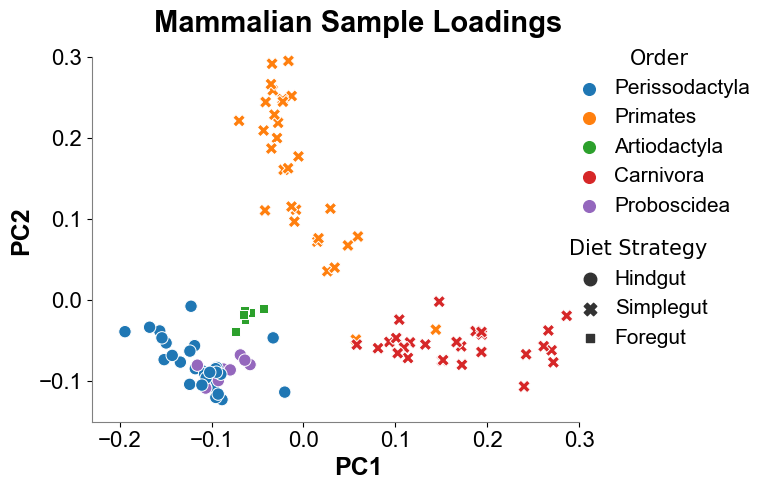

In [ ]:
fig, ax = plt.subplots(1,1,figsize=(8, 5), constrained_layout=True)

sns.scatterplot(x='PC1', y='PC2', hue='Order', style='digestive_strategy', 
                s=80, data=mammalian_plt)
ax.set_xlabel('PC1', color='black', weight='bold',
              fontsize=18, fontname='Arial')
ax.set_ylabel('PC2', color='black', weight='bold',
              fontsize=18, fontname='Arial')
ax.set_title('Mammalian Sample Loadings', 
             color='black', weight='bold',
             fontsize=21, fontname='Arial')

# fix backround
ax.set_facecolor('white')
ax.set_axisbelow(True)
sns.despine()
for child in ax.get_children():
    if isinstance(child, matplotlib.spines.Spine):
        child.set_color('grey')

for tick in ax.get_yticklabels():
    tick.set_fontproperties('arial')
    tick.set_color("black")
    tick.set_fontsize(16)
for tick in ax.get_xticklabels():
    tick.set_fontproperties('arial')
    tick.set_color("black")
    tick.set_fontsize(16)

handles, labels = ax.get_legend_handles_labels()
num_hue = mammalian_plt['Order'].nunique()

# Add second legend for style
legend2 = ax.legend(
    handles[7:],
    labels[7:],
    title='Diet Strategy', loc='upper right',
    fancybox=True, framealpha=.0,
    ncol=1, markerscale=1.5,
    borderaxespad=0,
    handletextpad=0.2,     # space between marker and text
    labelspacing=0.5,      # space between entries
    bbox_to_anchor=(1.17, 0.5),
    prop={'size':15, 'family':'Arial'})
legend2.get_title().set_fontsize('15')
legend2._legend_box.align = "center"

# Recreate the legend with custom titles
legend1 = ax.legend(
    handles[1:6], labels[1:6],
    title='Order', loc='upper right',
    fancybox=True, framealpha=.0,
    ncol=1, markerscale=1.4,
    borderaxespad=0,
    handletextpad=0.2,     # space between marker and text
    labelspacing=0.5,      # space between entries
    bbox_to_anchor=(1.25, 1),
    prop={'size':15, 'family':'Arial'})
legend1.get_title().set_fontsize('15')
legend1._legend_box.align = "center"

ax.add_artist(legend2)
ax.set_ylim(-0.15, 0.32)
ax.set_xlim(-0.23, 0.35)
ax.spines['left'].set_bounds(-0.15, 0.3)
ax.spines['bottom'].set_bounds(-0.23, 0.3)

plt.tight_layout()
plt.show()

### 5E

In [76]:
pr_curve = pd.read_csv(f'{source_path}/Figure 5/E/PR_curve_values.csv')

In [77]:
color_map_short = {
    ('gcms', 'Joint-RPCA'):'#0571b0',
    ('all', 'RPCA-aggregated'):'#f4a582',
    ('all', 'Joint-RPCA-aggregated'):'lightsteelblue',
    ('gcms', 'RPCA'):'#ca0020',
    ('microbiome', 'Joint-RPCA'):'#0571b0',
    ('microbiome', 'RPCA'):'#ca0020'}

label_ = {'gcms':'Metabolomics (GCMS)', 
         'lipid_neg':'Lipidomics (-)', 
         'lipid_polar':'Metabolomics (semi-polar)', 
         'lipid_pos':'Lipidomics (+)' ,
         'microbiome':'Microbiome (16S)',
         'all':'All omics'}

pairs = [('gcms', 'Joint-RPCA'), ('gcms', 'RPCA'), 
         ('all', 'Joint-RPCA-aggregated'),('all', 'RPCA-aggregated')]

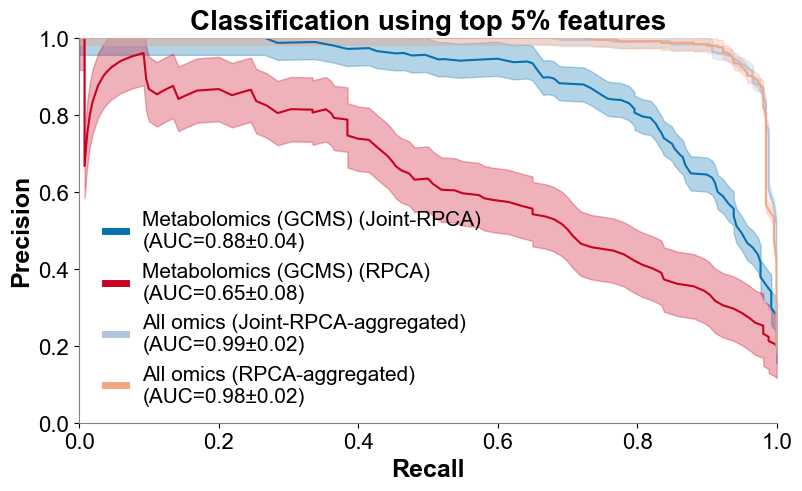

In [78]:
#for source data
curve_dfs = []

fig, ax = plt.subplots(1,1,figsize=(9, 5))
for pair in pairs:

    sub = pr_curve[(pr_curve['dataset'] == pair[0]) &
                   (pr_curve['method'] == pair[1])].copy()

    mean_ap = sub['mean_precision'].iloc[0]
    sd_ap = sub['sd_precision'].iloc[0]

    ax.plot(sub['recall'], sub['precision'], 
            c=color_map_short[pair],
            label='%s (%s)\n(AUC=%0.2f±%0.2f)' % (label_[pair[0]], pair[1],
                                                  mean_ap, sd_ap))
    ax.fill_between(sub['recall'], sub['precision_lower'],
                    sub['precision_upper'],
                    alpha=0.3, color=color_map_short[pair])

ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.0])
ax.set_xlabel('Recall', color='black', weight='bold', 
              fontsize=18, fontname='Arial')
ax.set_ylabel('Precision', color='black', weight='bold', 
              fontsize=18, fontname='Arial')
ax.set_title('Classification using top 5% features', 
             color='black', weight='bold', 
             fontsize=20, fontname='Arial')
# fix backround
ax.set_facecolor('white')
ax.set_axisbelow(True)
sns.despine()
for child in ax.get_children():
    if isinstance(child, matplotlib.spines.Spine):
        child.set_color('grey')
for tick in ax.get_yticklabels():
    tick.set_fontproperties('arial')
    tick.set_color("black")
    tick.set_fontsize(16)
for tick in ax.get_xticklabels():
    tick.set_fontproperties('arial')
    tick.set_color("black")
    tick.set_fontsize(16)
legend = ax.legend(loc=2, 
        bbox_to_anchor=(.01, .6),
        prop={'size':15, 'family':'Arial'},
        title="", fancybox=True, framealpha=.0,
        ncol=1, markerscale=1, handlelength=1)

# increase the line width in the legend 
for line in legend.get_lines()[:]:
    line.set_linewidth(5.0)
for line in legend.get_lines()[:]:
    line.set_linewidth(5.0)
plt.show()

### 5F

In [70]:
all_feat_metrics = pd.read_csv(f'{source_path}/Figure 5/F/all-features_metrics.csv', index_col=0)
display(all_feat_metrics.head())

,Fold,APR,AUC,APR_error,AUC_error
0,1,0.868882,0.943787,0.131118,0.056213
1,2,0.956693,0.986501,0.043307,0.013499
2,3,0.942612,0.982064,0.057388,0.017936
3,4,0.808723,0.948780,0.191277,0.051220
4,5,0.891635,0.945081,0.108365,0.054919


In [71]:
comparison_metrics = pd.read_csv(f'{source_path}/Figure 5/F/Joint-RPCA_vs_RPCA_metrics.csv', index_col=0)
display(comparison_metrics.head())

,n_feats,modality,selection,fold,APR,AUC
0,5,gcms,Joint-RPCA,0,0.775525,0.918639
1,5,gcms,Joint-RPCA,1,0.898672,0.938425
2,5,gcms,Joint-RPCA,2,0.897284,0.965237
3,5,gcms,Joint-RPCA,3,0.850574,0.930658
4,5,gcms,Joint-RPCA,4,0.917310,0.958210


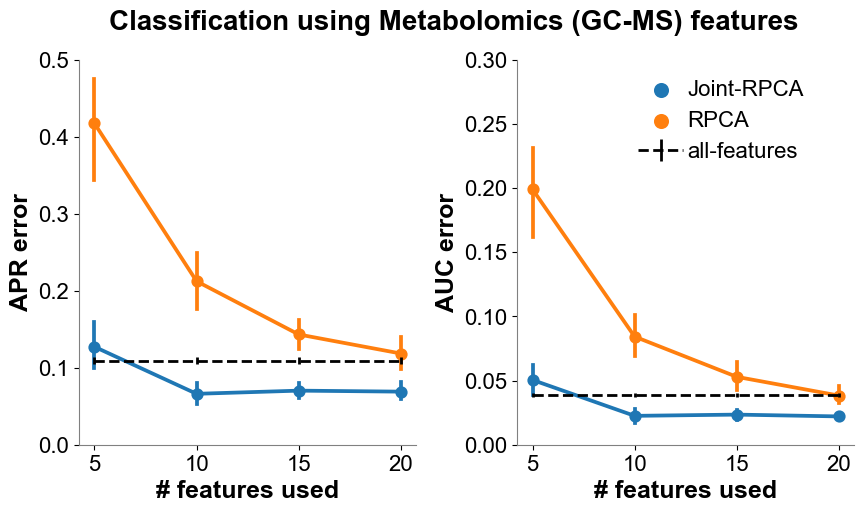

In [69]:
lims_ = {'gcms':[0.5,0.3]}
label_ = {'gcms':'Metabolomics (GC-MS)'}

for modality_name, modality_df in comparison_metrics.groupby('modality'):

    all_scores_sumamry_df_plt = modality_df.copy()
    all_scores_sumamry_df_plt['APR'] = 1 - all_scores_sumamry_df_plt['APR']
    all_scores_sumamry_df_plt['AUC'] = 1 - all_scores_sumamry_df_plt['AUC']

    fig, axn = plt.subplots(1,2,figsize=(10, 5))

    sns.pointplot(x='n_feats', y='APR', hue='selection', data=all_scores_sumamry_df_plt, ax=axn[0])
    x_ticks_ = axn[0].get_xticks()
    mean_ = [1 - np.mean(all_feat_metrics['APR'])] * len(x_ticks_)
    std_ = [np.std(all_feat_metrics['APR'])/len(all_feat_metrics['APR'])] * len(x_ticks_)
    axn[0].errorbar(x_ticks_, mean_, yerr=std_, label='all-features', color='black', lw=2, ls='--')
    axn[0].legend_.remove()
    axn[0].set_ylim(0, lims_[modality_name][0])
    axn[0].set_ylabel('APR error', color='black', weight='bold',
                      fontsize=18, fontname='Arial')
    
    sns.pointplot(x='n_feats', y='AUC', hue='selection', data=all_scores_sumamry_df_plt, ax=axn[1])
    x_ticks_ = axn[1].get_xticks()
    mean_ = [1 - np.mean(all_feat_metrics['AUC'])] * len(x_ticks_)
    std_ = [np.std(all_feat_metrics['AUC'])/len(all_feat_metrics['AUC'])] * len(x_ticks_)
    axn[1].errorbar(x_ticks_, mean_, yerr=std_, label='all-features', color='black', lw=2, ls='--')
    axn[1].set_ylim(0, lims_[modality_name][1])
    axn[1].set_ylabel('AUC error', color='black', weight='bold',
                      fontsize=18, fontname='Arial')
        
    for ax in axn:
        ax.set_xlabel('# features used', color='black', weight='bold',
                      fontsize=18, fontname='Arial')
        # fix backround
        ax.set_facecolor('white')
        ax.set_axisbelow(True)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_visible(True)
        ax.spines['bottom'].set_visible(True)
        ax.spines['top'].set_visible(False)
        for child in ax.get_children():
            if isinstance(child, matplotlib.spines.Spine):
                child.set_color('grey')

        for tick in ax.get_yticklabels():
            tick.set_fontproperties('arial')
            tick.set_color("black")
            tick.set_fontsize(16)
        for tick in ax.get_xticklabels():
            tick.set_fontproperties('arial')
            tick.set_color("black")
            tick.set_fontsize(16)
        
    legend = ax.legend(loc=2, 
               bbox_to_anchor=(0.3, 1),
               prop={'size':16, 'family':'Arial'},
               title="", fancybox=True, framealpha=.0,
               handletextpad=0.2, ncol=1, markerscale=1.3)
    # increase the line width in the legend 
    for line in legend.get_lines()[:]:
        line.set_linewidth(2.0)
    for line in legend.get_lines()[:]:
        line.set_linewidth(2.0)

    plt.subplots_adjust(wspace=0.3)
    
    plt.suptitle("Classification using %s features" %label_[modality_name], 
                 color='black', weight='bold',
                 fontsize=20, fontname='Arial')
    plt.show()